In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

import zuko
import torch

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset

In [2]:
data_dir = Path('datasets')
X = pd.read_csv(filepath_or_buffer=data_dir / 'natural_disaster_county.csv', )
X.drop(columns=['Unnamed: 0'], inplace=True)

In [3]:
X.head()

,STATE,CZ_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,...,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos,TOT_POP,land_sq_mi,water_sq_mi
0,SOUTH CAROLINA,C,2016-07-15 17:15:00,2016-07-15 17:15:00,2000.0,0,45091,0.0,0.0,0.0,...,-0.258819,-0.238033,-0.971257,-0.965926,-2.588190e-01,-0.238033,-0.971257,283862.0,682.45,13.27
1,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,159294.0,206.10,3.52
2,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,314024.0,523.45,9.76
3,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,314024.0,523.45,9.76
4,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,159294.0,206.10,3.52


In [4]:
display(X.columns)
display(X.shape)
display(X.describe())

Index(['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES',
       'CASUALTIES', 'FIPS', 'EVENT_TYPE_0', 'EVENT_TYPE_1', 'EVENT_TYPE_2',
       'EVENT_TYPE_3', 'EVENT_TYPE_4', 'EVENT_TYPE_5', 'EVENT_TYPE_6',
       'EVENT_TYPE_7', 'EVENT_TYPE_8', 'BEGIN_HOUR_sin', 'BEGIN_HOUR_cos',
       'BEGIN_DOY_sin', 'BEGIN_DOY_cos', 'END_HOUR_sin', 'END_HOUR_cos',
       'END_DOY_sin', 'END_DOY_cos', 'TOT_POP', 'land_sq_mi', 'water_sq_mi'],
      dtype='object')

(126307, 27)

,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,EVENT_TYPE_3,EVENT_TYPE_4,EVENT_TYPE_5,EVENT_TYPE_6,...,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos,TOT_POP,land_sq_mi,water_sq_mi
count,1.263070e+05,126307.000000,126307.000000,126307.000000,126307.0,126307.000000,126307.000000,126307.000000,126307.000000,126307.000000,...,126307.000000,126307.000000,126307.000000,1.263070e+05,126307.000000,126307.000000,126307.000000,1.263070e+05,126307.000000,126307.000000
mean,6.775625e+05,0.039729,30237.297561,0.368499,0.0,0.456261,0.000032,0.082181,0.000040,0.092988,...,-0.149025,0.149338,-0.435624,-3.759215e-01,-0.112895,0.147554,-0.438288,2.282988e+05,1242.875216,52.163939
std,5.279111e+07,1.427472,15061.120413,0.482400,0.0,0.498085,0.005627,0.274641,0.006292,0.290416,...,0.628971,0.678379,0.572484,6.609895e-01,0.639560,0.678408,0.570876,5.704496e+05,1950.812282,176.811425
min,0.000000e+00,0.000000,1001.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-0.999963,-1.000000,-1.000000e+00,-1.000000,-0.999963,-1.000000,6.700000e+01,0.000000,0.000000
25%,0.000000e+00,0.000000,19137.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.707107,-0.492548,-0.902030,-9.659258e-01,-0.707107,-0.492548,-0.902030,1.411300e+04,517.390000,2.240000
50%,0.000000e+00,0.000000,29189.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.258819,0.271234,-0.653680,-7.071068e-01,-0.258819,0.271234,-0.666575,4.214800e+04,719.950000,7.670000
75%,0.000000e+00,0.000000,45063.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.258819,0.789418,-0.111355,1.224647e-16,0.500000,0.789418,-0.111355,1.683520e+05,1055.800000,22.930000
max,1.000010e+10,234.000000,56045.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.999963,1.000000,1.000000e+00,1.000000,0.999963,1.000000,9.996634e+06,88817.120000,5945.530000


It's important to scale the data because Normalizing Flows try to learn an invertible function $f$ which map our complex (context) data $X$ in a "standard" distribution. If we pass skewed data in strange distribution our model struggle first to transpose this data into a standard distribution, and only then it can try to learn how to model this distribution. 

It's important to use different scaler for the target and the context because with the function scaler.inverse_transform() (of the scaler from sklearn StandardScaler) we can take our standardized data back to their original distribution.
During training our model will reason only in term of standardized data, but when we inference a new natural disaster we want to know the amount of damage not in term of a standard value but with a real value, and saving the mean and the standard deviation before pass our data to the model we can do that.

In [5]:
# Standardize surfaces and population with one scaler
context_scaler = StandardScaler()
X[['TOT_POP', 'land_sq_mi', 'water_sq_mi']] = context_scaler.fit_transform(X[['TOT_POP', 'land_sq_mi', 'water_sq_mi']])

In [6]:
# Standardize damages with another scaler
target_scaler = StandardScaler()
X[['DAMAGES']] = target_scaler.fit_transform(X[['DAMAGES']])

In [7]:
X.describe()

,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,EVENT_TYPE_3,EVENT_TYPE_4,EVENT_TYPE_5,EVENT_TYPE_6,...,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos,TOT_POP,land_sq_mi,water_sq_mi
count,1.263070e+05,126307.000000,126307.000000,126307.000000,126307.0,126307.000000,126307.000000,126307.000000,126307.000000,126307.000000,...,126307.000000,126307.000000,126307.000000,1.263070e+05,126307.000000,126307.000000,126307.000000,1.263070e+05,1.263070e+05,1.263070e+05
mean,1.350125e-18,0.039729,30237.297561,0.368499,0.0,0.456261,0.000032,0.082181,0.000040,0.092988,...,-0.149025,0.149338,-0.435624,-3.759215e-01,-0.112895,0.147554,-0.438288,-5.400501e-18,1.800167e-17,4.770442e-17
std,1.000004e+00,1.427472,15061.120413,0.482400,0.0,0.498085,0.005627,0.274641,0.006292,0.290416,...,0.628971,0.678379,0.572484,6.609895e-01,0.639560,0.678408,0.570876,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.283483e-02,0.000000,1001.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-0.999963,-1.000000,-1.000000e+00,-1.000000,-0.999963,-1.000000,-4.000927e-01,-6.371090e-01,-2.950270e-01
25%,-1.283483e-02,0.000000,19137.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.707107,-0.492548,-0.902030,-9.659258e-01,-0.707107,-0.492548,-0.902030,-3.754700e-01,-3.718903e-01,-2.823581e-01
50%,-1.283483e-02,0.000000,29189.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.258819,0.271234,-0.653680,-7.071068e-01,-0.258819,0.271234,-0.666575,-3.263243e-01,-2.680562e-01,-2.516473e-01
75%,-1.283483e-02,0.000000,45063.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.258819,0.789418,-0.111355,1.224647e-16,0.500000,0.789418,-0.111355,-1.050874e-01,-9.589644e-02,-1.653403e-01
max,1.894156e+02,234.000000,56045.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.999963,1.000000,1.000000e+00,1.000000,0.999963,1.000000,1.712399e+01,4.489135e+01,3.333150e+01


# NSF

### Prepare training and test sets

In [8]:
y = X['DAMAGES'].copy()
X = X.drop(columns=['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES', 'CASUALTIES', 'FIPS'])
print(X.shape, y.shape)

(126307, 20) (126307,)


In [9]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Convert data to numpy
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np = X_test.values
y_test_np = y_test.values

# Convert to pytorch tensor
train_context = torch.tensor(X_train_np, dtype=torch.float32)
train_damage = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)  # Shape: (N, 1)
test_context = torch.tensor(X_test_np, dtype=torch.float32)
test_damage = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

print(f"train_context shape: {train_context.shape}")
print(f"train_damage shape: {train_damage.shape}")

train_context shape: torch.Size([101045, 20])
train_damage shape: torch.Size([101045, 1])


### Create the model

In [11]:
# Configuration parameters
n_context_features = train_context.shape[1] # what we pass to the model as conditions
n_sample_feature = 1    # what we want to predict (the damage)

In [12]:
flow = zuko.flows.NSF(
    features=n_sample_feature,
    context=n_context_features,
    transforms=5,   # number of transformation layers
    hidden_features=[128, 128, 128]    # hidden layer sizes in the NN
)

print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 193395 parameters


### Training

In [13]:
# Training parameters
n_epochs = 50
lr=1e-3
batch_size=256

In [14]:
# Prepare the data
train_dataset = torch.utils.data.TensorDataset(train_context, train_damage)
test_dataset = torch.utils.data.TensorDataset(test_context, test_damage)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [15]:
# Setup optimizer
optimizer = torch.optim.Adam(flow.parameters(), lr=lr)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

La loss (Negative Log Likelihood) può essere negativa (perché è log-densità, non probabilità semplice). L'importante è che diminuisca nel tempo (diventi "più negativa" o scenda verso valori più bassi).

In [17]:
# Training loop
tot_losses = []
flow = flow.to(device)
print(f"Training with {device}")

for epoch in range(n_epochs):
    losses = []
    for context_batch, damage_batch in train_loader:
        context_batch = context_batch.to(device)
        damage_batch = damage_batch.to(device)

        loss = -flow(context_batch).log_prob(damage_batch).mean()
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)

        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.detach())

    losses = torch.stack(losses)
    tot_losses.append(losses.mean().item())


    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch\t[{epoch+1}/{n_epochs}]\tTrain Loss: {tot_losses[-1]:.4f}\t± {losses.std().item()}")

Training with cuda
Epoch	[1/50]	Train Loss: -1.6648	± 4.314276218414307
Epoch	[5/50]	Train Loss: -1.9740	± 4.3788228034973145
Epoch	[10/50]	Train Loss: -2.4918	± 4.42144775390625
Epoch	[15/50]	Train Loss: -3.2194	± 4.417576789855957
Epoch	[20/50]	Train Loss: -3.6611	± 4.307472229003906
Epoch	[25/50]	Train Loss: -3.7420	± 4.381150245666504
Epoch	[30/50]	Train Loss: -4.0562	± 4.3544816970825195
Epoch	[35/50]	Train Loss: -3.1512	± 4.691041946411133
Epoch	[40/50]	Train Loss: -4.7187	± 4.248554229736328
Epoch	[45/50]	Train Loss: -5.1077	± 4.19954252243042
Epoch	[50/50]	Train Loss: -5.2426	± 4.18851900100708


La deviazione standard ti dice quanto è diversa la performance del modello tra un batch e l'altro all'interno della stessa epoca.

Bassa Std: Il modello sbaglia (o indovina) allo stesso modo su tutti i batch. È coerente.

Alta Std: Ci sono batch "facili" dove il modello va benissimo (loss molto bassa) e batch "difficili" o "strani" dove il modello va nel panico (loss altissima).

Dovrebbe diminuire nel tempo. Tuttavia, con dati di disastri naturali (che sono spesso "heavy-tailed", cioè con eventi rari ed estremi), la Std potrebbe rimanere un po' alta.

Se la Std rimane enorme (es. 10 o 20) mentre la Loss media non scende, significa che il modello non riesce a gestire gli outlier (i disastri estremi gli rompono le previsioni).

Come stabilizzare il training? (e quindi ridurre la standard deviation?):
- aumenta la batch size (gpu permettendo)
- gradient clipping (impedisce ad un singolo batch sfortunato, che quindi genera gradienti molto grandi, di distruggere i pesi del modello)

### Inference

In [23]:
def predict_with_uncertainty(flow, context, n_samples=1000):
    # context shape: (Batch, Features)
    # if Batch size = 1 (un solo sample) accertati di aggiungere .unsqueeze(0) per avere la dimensione del batch)
    flow.eval()
    with torch.no_grad():
        samples = flow(context).sample((n_samples,)) # Shape: (n_samples, Batch_size, output_feature(=1))
        
        pred_norm = samples.mean(dim=0).cpu().numpy()  # Expected value (for standard metrics)
        std_norm = samples.std(dim=0).cpu().numpy() # Uncertany

        predictions = target_scaler.inverse_transform(pred_norm)
        uncertainties = std_norm * target_scaler.scale_
        
    return predictions, uncertainties

Inizio inferenza sul Test Set...
Inferenza completata su 25262 eventi.

RISULTATI DEL MODELLO (in scala reale)
MAE (Errore Medio Assoluto):  1,210,531.88 $
RMSE (Errore Quadratico Medio): 77,598,709.51 $
R2 Score: -0.0000


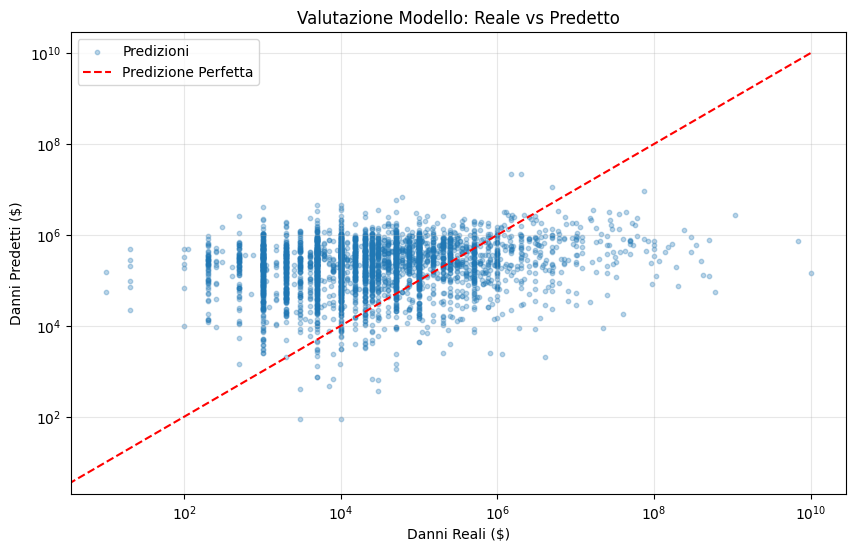


Esempi di predizione con incertezza:
Evento 0: Reale: -0 $ | Predetto: -32,775 $ ± 273,964
Evento 1: Reale: -0 $ | Predetto: -32,831 $ ± 129,490
Evento 2: Reale: -0 $ | Predetto: 132,756 $ ± 4,028,326
Evento 3: Reale: -0 $ | Predetto: 29,767 $ ± 1,418,726
Evento 4: Reale: -0 $ | Predetto: -6,994 $ ± 624,738


In [24]:
# Prediction on the test set

# Liste per salvare i risultati di tutti i batch
all_preds = []
all_uncertainties = []
all_targets = []

print("Inizio inferenza sul Test Set...")

# Iteriamo sui batch del test set per non saturare la memoria
for context_batch, damage_batch in test_loader:
    context_batch = context_batch.to(device)
    
    # 1. Predizione (La tua funzione restituisce già valori denormalizzati/reali)
    # Nota: Assicurati che predict_with_uncertainty gestisca il .cpu().numpy() internamente
    # se la stai usando come definita sopra, altrimenti potrebbe dare errore sui device.
    # Qui assumo restituisca numpy arrays.
    preds_real, unc_real = predict_with_uncertainty(flow, context_batch, n_samples=1000)
    
    # 2. Gestione del Target Reale (Ground Truth)
    # Dobbiamo denormalizzare anche i dati veri per poterli confrontare
    targets_real = target_scaler.inverse_transform(damage_batch.cpu().numpy())
    
    # 3. Accumulo risultati
    all_preds.append(preds_real)
    all_uncertainties.append(unc_real)
    all_targets.append(targets_real)

# Concateniamo tutti i batch in un unico array numpy
y_pred = np.concatenate(all_preds, axis=0)
y_std = np.concatenate(all_uncertainties, axis=0)
y_true = np.concatenate(all_targets, axis=0)

print(f"Inferenza completata su {len(y_pred)} eventi.")

# --- CALCOLO METRICHE ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n" + "="*30)
print("RISULTATI DEL MODELLO (in scala reale)")
print("="*30)
print(f"MAE (Errore Medio Assoluto):  {mae:,.2f} $")
print(f"RMSE (Errore Quadratico Medio): {rmse:,.2f} $")
print(f"R2 Score: {r2:.4f}")
print("="*30)

# --- GRAFICO: Predetto vs Reale ---
plt.figure(figsize=(10, 6))
# Facciamo un plot in scala logaritmica perché i danni variano di ordini di grandezza
# Aggiungiamo +1 per evitare log(0)
plt.scatter(y_true, y_pred, alpha=0.3, s=10, label='Predizioni')

# Linea di perfezione (y = x)
p1 = max(y_true.max(), y_pred.max())
p2 = min(y_true.min(), y_pred.min())
plt.plot([p1, p2], [p1, p2], 'r--', label='Predizione Perfetta')

plt.xlabel('Danni Reali ($)')
plt.ylabel('Danni Predetti ($)')
plt.title('Valutazione Modello: Reale vs Predetto')
plt.xscale('log') # Consigliato per danni economici
plt.yscale('log') # Consigliato per danni economici
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- ESEMPIO DI INCERTEZZA ---
# Mostriamo i primi 5 casi con la loro incertezza
print("\nEsempi di predizione con incertezza:")
for i in range(5):
    print(f"Evento {i}: Reale: {y_true[i][0]:,.0f} $ | Predetto: {y_pred[i][0]:,.0f} $ ± {y_std[i][0]:,.0f}")

Inizio inferenza sul Test Set...
Inferenza completata su 25262 eventi.

RISULTATI DEL MODELLO (Scala Reale)
MAE (Errore Medio Assoluto):  1,210,921.75 $
RMSE (Errore Quadratico Medio): 77,596,793.05 $
R2 Score: 0.0000

TOP 5 CATASTROFI NEL TEST SET (Danni > 0)
Evento #23389:
  Reale:    10,000,100,352 $
  Predetto: 690,467 $ (± 9,096,080)
  Errore:   9,999,410,176 $
--------------------
Evento #1142:
  Reale:    7,000,009,728 $
  Predetto: 603,970 $ (± 7,500,667)
  Errore:   6,999,405,568 $
--------------------
Evento #18173:
  Reale:    1,090,000,000 $
  Predetto: 1,547,352 $ (± 10,900,603)
  Errore:   1,088,452,608 $
--------------------
Evento #13030:
  Reale:    600,010,048 $
  Predetto: 173,076 $ (± 2,628,214)
  Errore:   599,836,992 $
--------------------
Evento #8580:
  Reale:    500,000,032 $
  Predetto: 436,124 $ (± 4,608,777)
  Errore:   499,563,904 $
--------------------


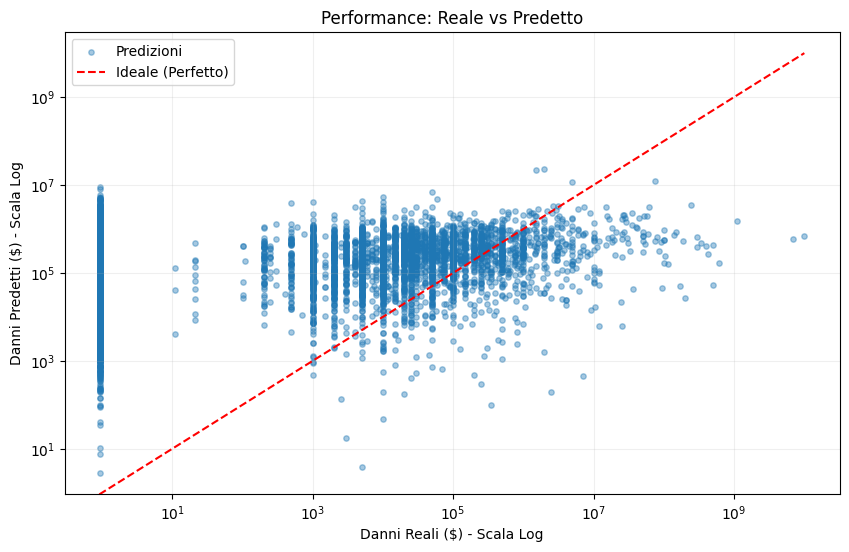

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. INFERENZA SULL'INTERO TEST SET
# ==========================================
all_preds = []
all_uncertainties = []
all_targets = []

print("Inizio inferenza sul Test Set...")
flow.eval() # Fondamentale: mette il modello in modalità valutazione

# Iteriamo sui batch per efficienza
for context_batch, damage_batch in test_loader:
    context_batch = context_batch.to(device)
    
    # --- A. Predizione ---
    # Chiamiamo la tua funzione (che deve restituire numpy array)
    # Se la tua funzione restituisce tensor, aggiungi .cpu().numpy() qui sotto
    preds_real, unc_real = predict_with_uncertainty(flow, context_batch, n_samples=1000)
    
    # Se predict_with_uncertainty restituisce tensori, convertiamoli:
    if isinstance(preds_real, torch.Tensor):
        preds_real = preds_real.cpu().numpy()
    if isinstance(unc_real, torch.Tensor):
        unc_real = unc_real.cpu().numpy()

    # --- B. Ground Truth (Target Reale) ---
    # Denormalizziamo i dati veri per il confronto
    targets_real = target_scaler.inverse_transform(damage_batch.cpu().numpy())
    
    # --- C. Accumulo ---
    all_preds.append(preds_real)
    all_uncertainties.append(unc_real)
    all_targets.append(targets_real)

# Creiamo array unici giganti
y_pred = np.concatenate(all_preds, axis=0)
y_std = np.concatenate(all_uncertainties, axis=0)
y_true = np.concatenate(all_targets, axis=0)

print(f"Inferenza completata su {len(y_pred)} eventi.")

# ==========================================
# 2. CALCOLO METRICHE
# ==========================================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n" + "="*40)
print("RISULTATI DEL MODELLO (Scala Reale)")
print("="*40)
print(f"MAE (Errore Medio Assoluto):  {mae:,.2f} $")
print(f"RMSE (Errore Quadratico Medio): {rmse:,.2f} $")
print(f"R2 Score: {r2:.4f}")

# ==========================================
# 3. VISUALIZZAZIONE ESEMPI CRITICI (>0)
# ==========================================
print("\n" + "="*40)
print("TOP 5 CATASTROFI NEL TEST SET (Danni > 0)")
print("="*40)

# Troviamo gli indici dove il danno reale è maggiore di zero
non_zero_indices = np.where(y_true > 100)[0] # Filtriamo > 100$ per evitare rumore minimo

if len(non_zero_indices) > 0:
    # Ordiniamo per trovare i danni maggiori (dal più grande al più piccolo)
    # y_true[non_zero_indices] prende solo i valori > 0
    # argsort li ordina, [::-1] inverte l'ordine (decrescente)
    sorted_indices = non_zero_indices[np.argsort(y_true[non_zero_indices].flatten())[::-1]]
    
    # Prendiamo i primi 5 (o meno se ce ne sono pochi)
    top_k = min(5, len(sorted_indices))
    
    for i in range(top_k):
        idx = sorted_indices[i]
        real_val = y_true[idx][0]
        pred_val = y_pred[idx][0]
        unc_val = y_std[idx][0]
        
        # Calcoliamo l'errore percentuale per questo singolo evento
        err_perc = abs(real_val - pred_val) / real_val * 100
        
        print(f"Evento #{idx}:")
        print(f"  Reale:    {real_val:,.0f} $")
        print(f"  Predetto: {pred_val:,.0f} $ (± {unc_val:,.0f})")
        print(f"  Errore:   {real_val - pred_val:,.0f} $")
        print("-" * 20)
else:
    print("Nessun evento con danni significativi (>100$) trovato nel test set.")

# ==========================================
# 4. PLOT (Scala Logaritmica)
# ==========================================
plt.figure(figsize=(10, 6))

# Aggiungiamo una piccola costante (epsilon) per evitare log(0)
epsilon = 1.0 
plt.scatter(y_true + epsilon, y_pred + epsilon, alpha=0.4, s=15, label='Predizioni')

# Linea ideale
p_min = min((y_true+epsilon).min(), (y_pred+epsilon).min())
p_max = max((y_true+epsilon).max(), (y_pred+epsilon).max())
plt.plot([p_min, p_max], [p_min, p_max], 'r--', label='Ideale (Perfetto)')

plt.xlabel('Danni Reali ($) - Scala Log')
plt.ylabel('Danni Predetti ($) - Scala Log')
plt.title('Performance: Reale vs Predetto')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()